# Notebook 2 - SPC Control Charts
## LumenOps 360 | LumenTech BV - Manufacturing Operations Intelligence

**Purpose:** Apply Statistical Process Control (SPC) to determine whether LumenTech's key manufacturing processes are in statistical control — or exhibiting assignable-cause variation that demands intervention.

**Framework Context:** SPC sits within the **DMAIC Control phase** — the final step of Six Sigma. After defining the problem (Page 1), measuring baselines (Pages 1–4), and analyzing root causes (EDA notebook), control charts answer the critical question: *"Is this process stable enough to predict, or are special causes driving unpredictable behavior?"*

**Charts in this notebook:**
1. **p-chart** — Proportion defective per production batch (Quality / FPY)
2. **np-chart** — Count of defective units per batch (absolute view)
3. **X-bar chart** — Daily OEE mean across lines (process centering)
4. **R-chart** — Daily OEE range across lines (process spread)
5. **I-MR chart** — Individual daily defect rate with Moving Range

**Key question:** Is LumenTech's quality process in statistical control at 96.65% FPY — or are there out-of-control signals that explain the gap to the 97% target?

---

In [1]:
# ── Imports ──────────────────────────────────────────────────────────
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# ── DuckDB Connection ────────────────────────────────────────────────
DB_PATH = Path("../data/lumenops.duckdb")
con = duckdb.connect(str(DB_PATH), read_only=True)
print(f"DuckDB v{con.execute('SELECT version()').fetchone()[0]} — connected to {DB_PATH.name}")

# ── LumenOps Design System ──────────────────────────────────────────
NAVY      = "#1B2A49"
EMBER     = "#E84A27"
STEEL     = "#6B8CAE"
SAGE      = "#4F7942"
CHARCOAL  = "#2D2D2D"
IVORY     = "#F5F3EE"

# SPC-specific colors
UCL_COLOR = EMBER       # Upper Control Limit — red/alert
LCL_COLOR = EMBER       # Lower Control Limit — same
CL_COLOR  = NAVY        # Center Line — navy
IN_CTRL   = STEEL       # Points in control
OUT_CTRL  = EMBER       # Points out of control

# ── Plot Defaults ────────────────────────────────────────────────────
sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.dpi": 150,
    "font.family": "Segoe UI",
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "figure.facecolor": IVORY,
    "axes.facecolor": "#FFFFFF",
    "grid.alpha": 0.3,
})

print("Design system loaded — SPC palette ready.")

DuckDB vv1.5.2 — connected to lumenops.duckdb
Design system loaded — SPC palette ready.


In [2]:
# ── Load QC inspection data (for p-chart, np-chart) ─────────────────
qc = con.execute("""
    SELECT 
        batch_id,
        stage,
        inspected_date,
        units_inspected,
        units_passed,
        units_rejected,
        defect_reason
    FROM main_staging.stg_qc_inspection
    ORDER BY inspected_date, batch_id
""").fetchdf()

# ── Load daily OEE data (for X-bar, R charts) ───────────────────────
oee = con.execute("""
    SELECT 
        production_date,
        line_id,
        availability,
        performance,
        quality,
        oee
    FROM main_intermediate.int_oee_daily
    ORDER BY production_date, line_id
""").fetchdf()

print(f"QC inspections loaded:  {qc.shape[0]:,} rows  |  {qc['inspected_date'].nunique()} unique dates")
print(f"OEE daily loaded:       {oee.shape[0]:,} rows  |  {oee['production_date'].nunique()} unique dates")
print(f"\nQC date range:  {qc['inspected_date'].min()}  →  {qc['inspected_date'].max()}")
print(f"OEE date range: {oee['production_date'].min()}  →  {oee['production_date'].max()}")

QC inspections loaded:  5,148 rows  |  468 unique dates
OEE daily loaded:       2,574 rows  |  468 unique dates

QC date range:  2023-01-02 00:00:00  →  2024-06-29 00:00:00
OEE date range: 2023-01-02 00:00:00  →  2024-06-29 00:00:00


In [3]:
# ── p-Chart: Daily Defect Rate ──────────────────────────────────────
# Aggregate QC inspections to daily level (all lines, all stages)
daily_qc = (
    qc.groupby("inspected_date")
    .agg(total_inspected=("units_inspected", "sum"),
         total_rejected=("units_rejected", "sum"))
    .reset_index()
)

# Proportion defective (p) per day
daily_qc["p"] = daily_qc["total_rejected"] / daily_qc["total_inspected"]

# ── Control Limits (variable sample size → per-point limits) ────────
p_bar = daily_qc["total_rejected"].sum() / daily_qc["total_inspected"].sum()
n_bar = daily_qc["total_inspected"].mean()

# Individual limits (exact, per-point sample size)
daily_qc["UCL"] = p_bar + 3 * np.sqrt(p_bar * (1 - p_bar) / daily_qc["total_inspected"])
daily_qc["LCL"] = p_bar - 3 * np.sqrt(p_bar * (1 - p_bar) / daily_qc["total_inspected"])
daily_qc["LCL"] = daily_qc["LCL"].clip(lower=0)  # LCL cannot go below 0

# Flag out-of-control points
daily_qc["out_of_control"] = (daily_qc["p"] > daily_qc["UCL"]) | (daily_qc["p"] < daily_qc["LCL"])

print(f"p̄ (overall defect rate):  {p_bar:.4f}  ({p_bar*100:.2f}%)")
print(f"n̄ (avg sample size/day):  {n_bar:.1f} units")
print(f"Avg UCL: {daily_qc['UCL'].mean():.4f}  |  Avg LCL: {daily_qc['LCL'].mean():.4f}")
print(f"\nOut-of-control points:    {daily_qc['out_of_control'].sum()} / {len(daily_qc)} days "
      f"({daily_qc['out_of_control'].mean()*100:.1f}%)")

p̄ (overall defect rate):  0.0213  (2.13%)
n̄ (avg sample size/day):  6217.2 units
Avg UCL: 0.0271  |  Avg LCL: 0.0155

Out-of-control points:    73 / 468 days (15.6%)


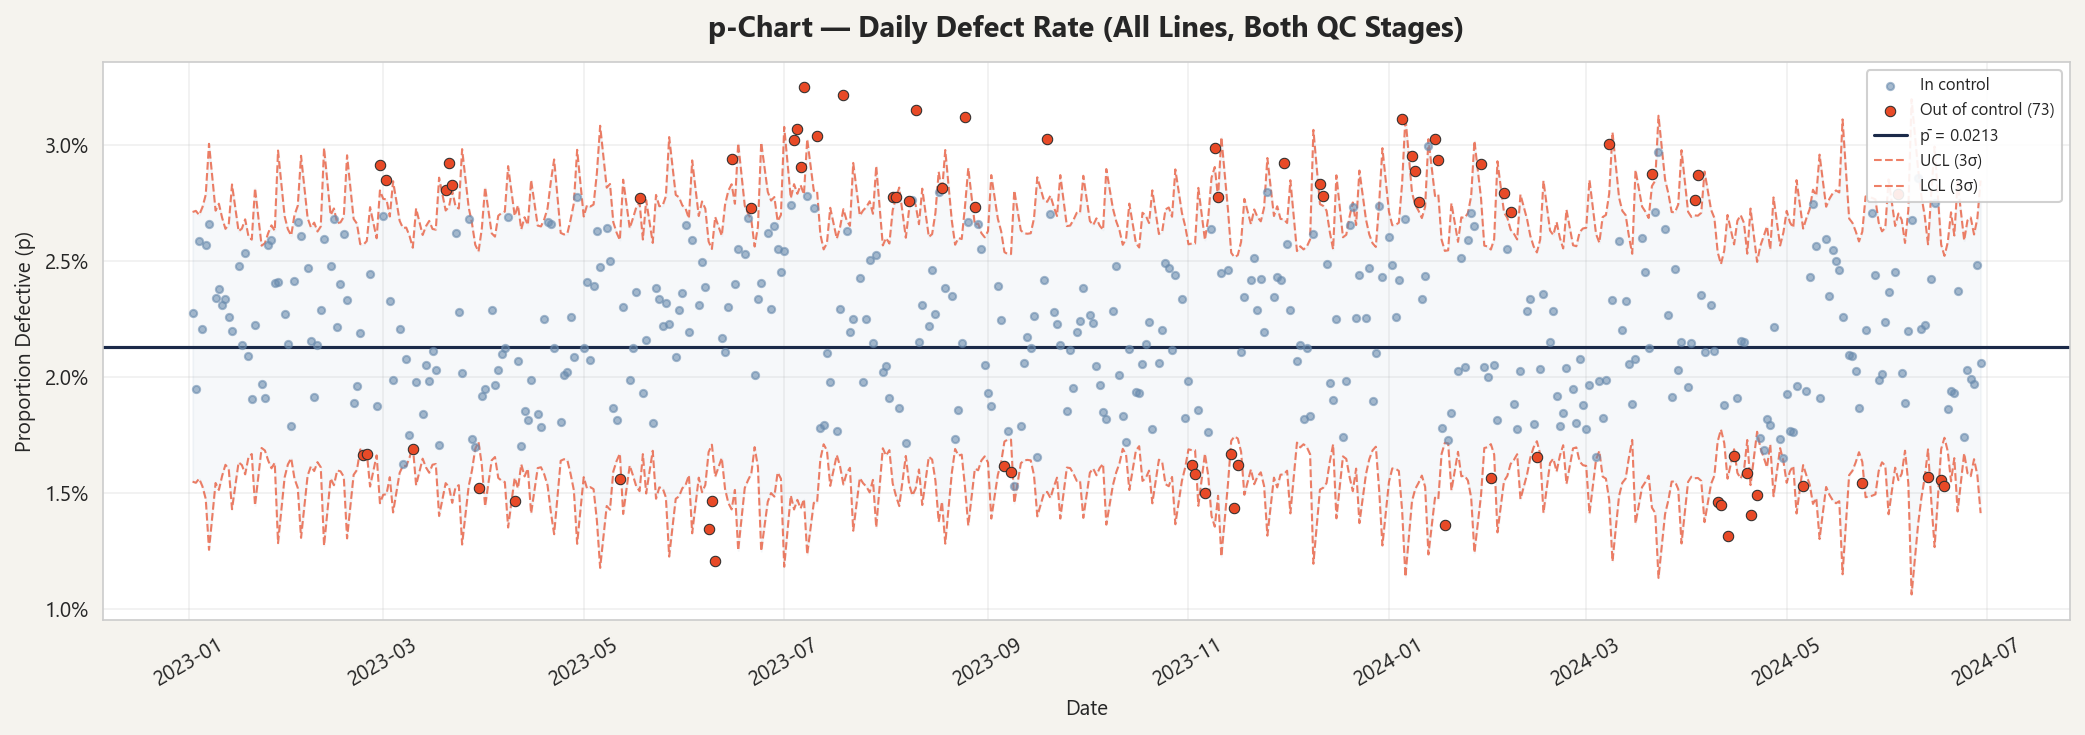

In [4]:
# ── p-Chart: Daily Proportion Defective ─────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

dates = daily_qc["inspected_date"]
mask_oc = daily_qc["out_of_control"]

# In-control points
ax.scatter(dates[~mask_oc], daily_qc.loc[~mask_oc, "p"],
           color=IN_CTRL, s=12, alpha=0.6, zorder=3, label="In control")

# Out-of-control points
ax.scatter(dates[mask_oc], daily_qc.loc[mask_oc, "p"],
           color=OUT_CTRL, s=25, edgecolors=CHARCOAL, linewidths=0.5,
           zorder=4, label=f"Out of control ({mask_oc.sum()})")

# Control lines
ax.axhline(p_bar, color=CL_COLOR, linewidth=1.5, linestyle="-", label=f"p̄ = {p_bar:.4f}")
ax.plot(dates, daily_qc["UCL"], color=UCL_COLOR, linewidth=1, linestyle="--", alpha=0.7, label="UCL (3σ)")
ax.plot(dates, daily_qc["LCL"], color=LCL_COLOR, linewidth=1, linestyle="--", alpha=0.7, label="LCL (3σ)")

# Fill between limits
ax.fill_between(dates, daily_qc["LCL"], daily_qc["UCL"], alpha=0.06, color=STEEL)

ax.set_title("p-Chart — Daily Defect Rate (All Lines, Both QC Stages)", fontsize=14, pad=12)
ax.set_xlabel("Date")
ax.set_ylabel("Proportion Defective (p)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
ax.tick_params(axis="x", rotation=30)

fig.tight_layout()
plt.show()

### p-Chart Interpretation

**Result: The process is NOT in statistical control.**

- **73 / 468 days (15.6%)** fall outside 3σ control limits — far exceeding the 0.27% expected from common-cause variation alone.
- Out-of-control points appear on **both sides**: defect spikes (above UCL) AND unusually clean days (below LCL).
- No visible trend or seasonal drift — the instability is **episodic**, suggesting multiple assignable causes (changeovers, staffing gaps, material batches) rather than a single systemic degradation.

**Implication for LumenTech BV:** Before setting a tighter FPY target (e.g., 97% → 98%), the process must first be *brought into control*. Tightening targets on an unstable process produces frustration, not improvement — a core SPC principle.

**Next:** Break down the p-chart by QC stage (Production vs. Packaging) to isolate where the instability originates.

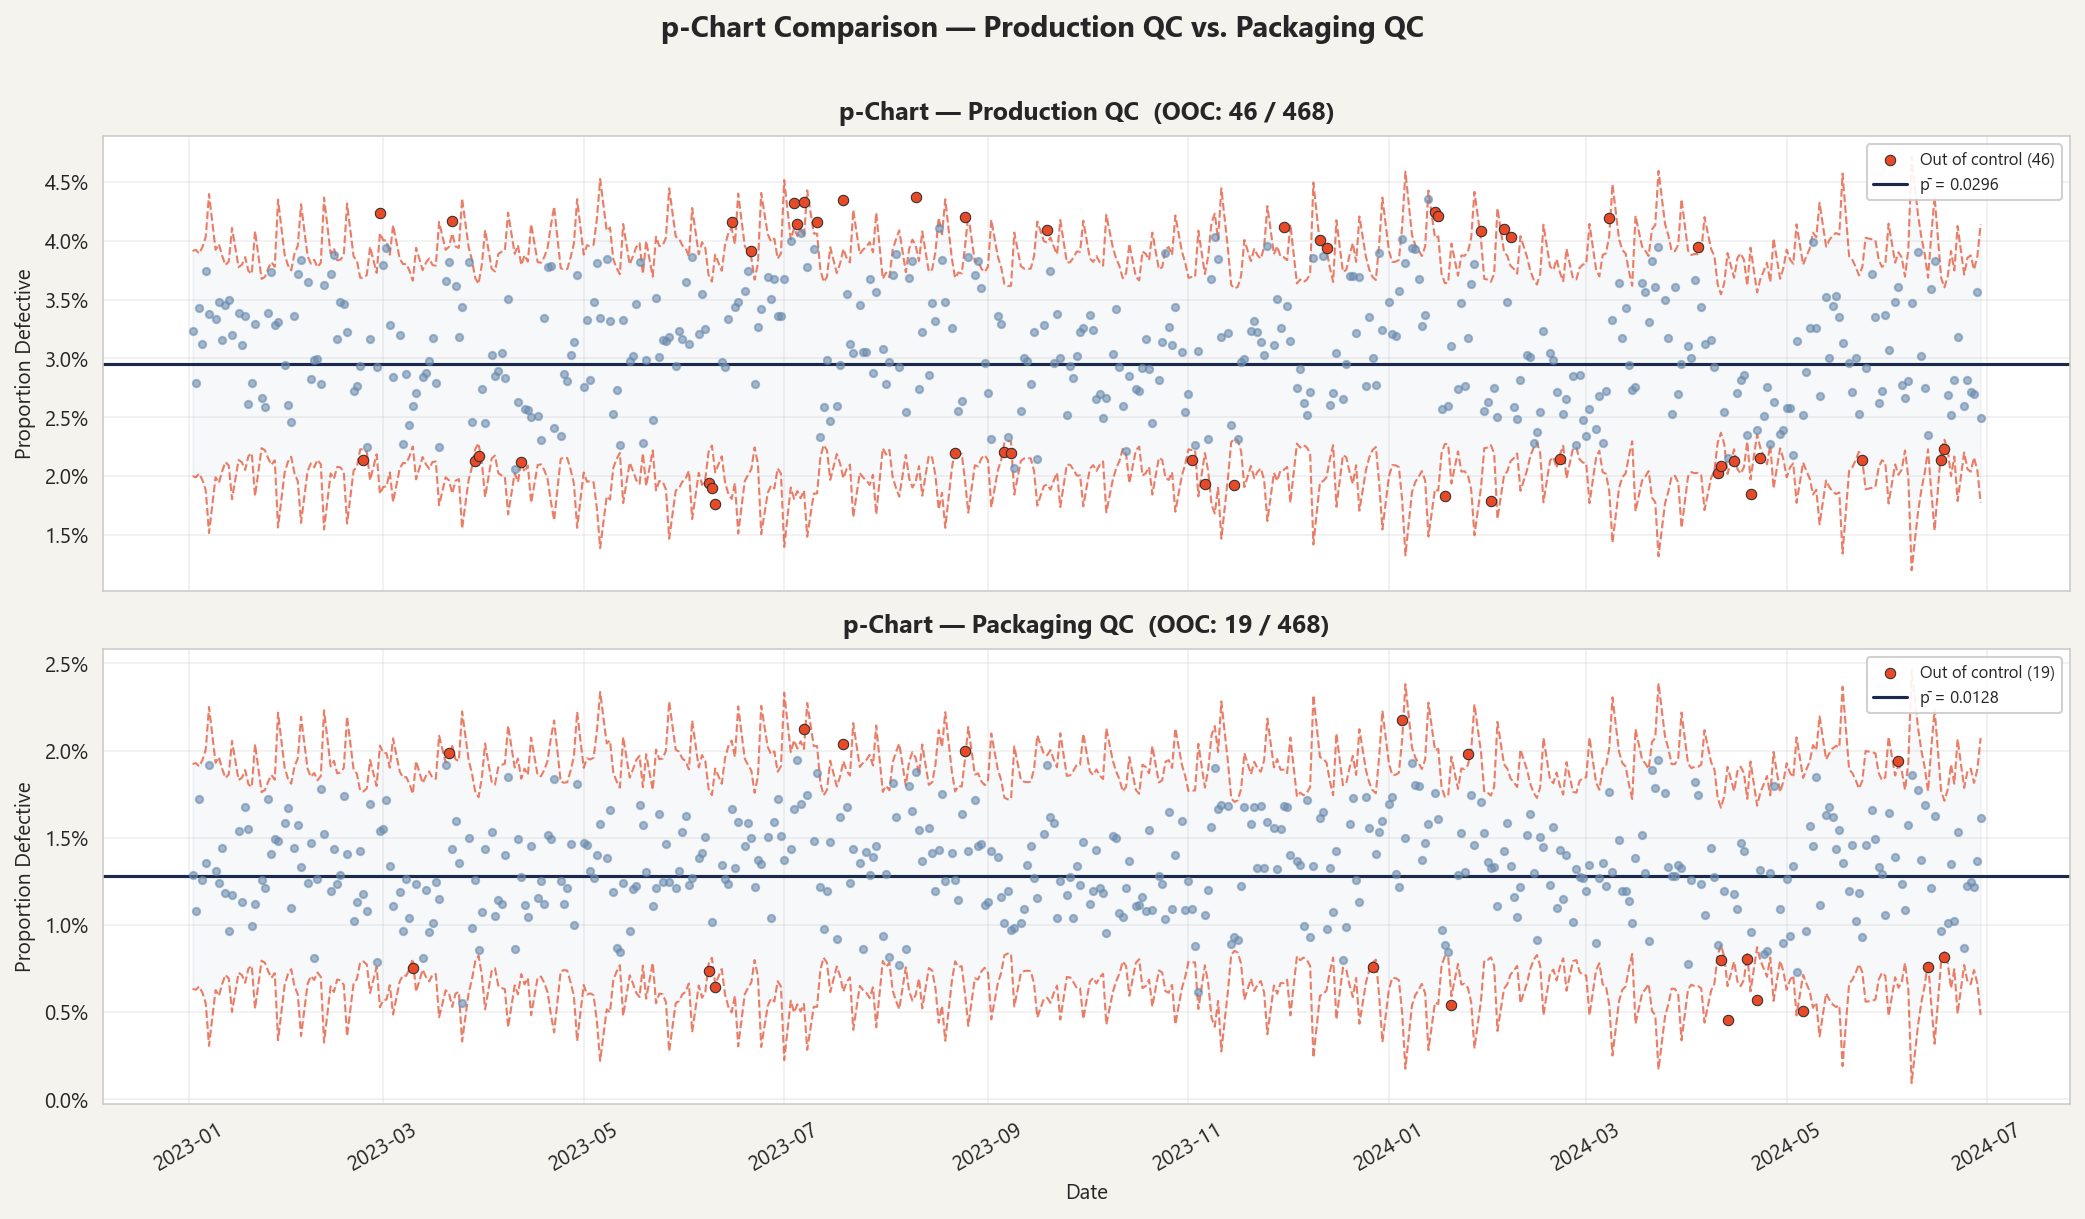

In [5]:
# ── p-Chart split by QC stage ───────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for i, stage in enumerate(["PRODUCTION_QC", "PACKAGING_QC"]):
    ax = axes[i]
    
    stage_qc = (
        qc[qc["stage"] == stage]
        .groupby("inspected_date")
        .agg(total_inspected=("units_inspected", "sum"),
             total_rejected=("units_rejected", "sum"))
        .reset_index()
    )
    stage_qc["p"] = stage_qc["total_rejected"] / stage_qc["total_inspected"]
    
    # Control limits
    p_bar_s = stage_qc["total_rejected"].sum() / stage_qc["total_inspected"].sum()
    stage_qc["UCL"] = p_bar_s + 3 * np.sqrt(p_bar_s * (1 - p_bar_s) / stage_qc["total_inspected"])
    stage_qc["LCL"] = (p_bar_s - 3 * np.sqrt(p_bar_s * (1 - p_bar_s) / stage_qc["total_inspected"])).clip(lower=0)
    stage_qc["out_of_control"] = (stage_qc["p"] > stage_qc["UCL"]) | (stage_qc["p"] < stage_qc["LCL"])
    
    dates = stage_qc["inspected_date"]
    mask_oc = stage_qc["out_of_control"]
    
    ax.scatter(dates[~mask_oc], stage_qc.loc[~mask_oc, "p"],
               color=IN_CTRL, s=12, alpha=0.6, zorder=3)
    ax.scatter(dates[mask_oc], stage_qc.loc[mask_oc, "p"],
               color=OUT_CTRL, s=25, edgecolors=CHARCOAL, linewidths=0.5,
               zorder=4, label=f"Out of control ({mask_oc.sum()})")
    
    ax.axhline(p_bar_s, color=CL_COLOR, linewidth=1.5, linestyle="-",
               label=f"p̄ = {p_bar_s:.4f}")
    ax.plot(dates, stage_qc["UCL"], color=UCL_COLOR, linewidth=1, linestyle="--", alpha=0.7)
    ax.plot(dates, stage_qc["LCL"], color=LCL_COLOR, linewidth=1, linestyle="--", alpha=0.7)
    ax.fill_between(dates, stage_qc["LCL"], stage_qc["UCL"], alpha=0.06, color=STEEL)
    
    stage_label = "Production QC" if stage == "PRODUCTION_QC" else "Packaging QC"
    ax.set_title(f"p-Chart — {stage_label}  (OOC: {mask_oc.sum()} / {len(stage_qc)})",
                 fontsize=12, pad=8)
    ax.set_ylabel("Proportion Defective")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
    ax.legend(loc="upper right", fontsize=8, framealpha=0.9)

axes[1].set_xlabel("Date")
axes[1].tick_params(axis="x", rotation=30)
fig.suptitle("p-Chart Comparison — Production QC vs. Packaging QC", fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

### p-Chart by QC Stage — Key Finding

| Stage | p̄ (Defect Rate) | OOC Points | OOC % |
|-------|-----------------|------------|-------|
| Production QC | 2.96% | 46 / 468 | 9.8% |
| Packaging QC | 1.28% | 19 / 468 | 4.1% |
| **Combined** | **2.13%** | **73 / 468** | **15.6%** |

**Diagnosis:** Production QC carries **70% of out-of-control signals** and runs at more than double the defect rate of Packaging QC. The assembly process — not the packaging line — is where quality instability originates.

**Action implication:** Efforts to bring the process into statistical control should prioritize Production QC defect types (FLICKER, SOLDER_FAIL, HOUSING_DAMAGE_ASSEMBLY, DRIVER_FAULT) before addressing Packaging QC issues (POOR_PACKAGING, DUST_CONTAMINATION).

**Next:** np-chart to see the same data in absolute defect counts — useful for plant managers who think in units, not proportions.

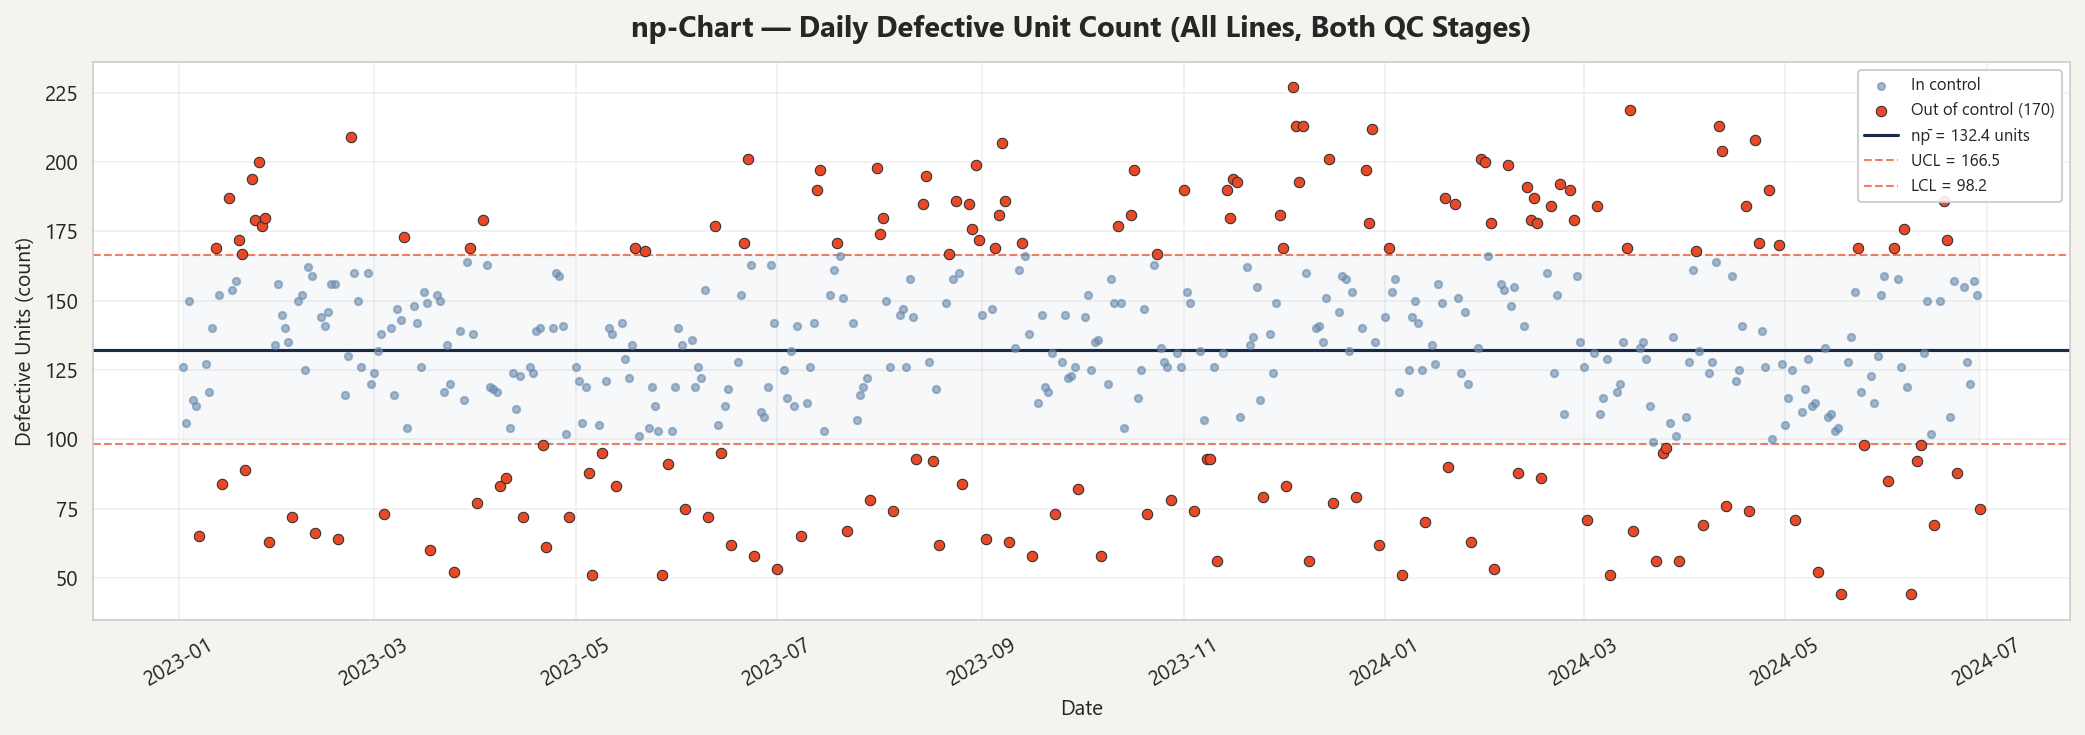


np̄ (expected daily defects): 132.4 units
UCL: 166.5  |  LCL: 98.2
Out-of-control: 170 / 468 days (36.3%)

Worst day: 2023-12-04  →  227 defective units


In [6]:
# ── np-Chart: Daily Count of Defective Units ────────────────────────
# Uses the same daily_qc dataframe from Cell 4

np_bar = p_bar * n_bar  # Expected defect count per day
daily_qc["np_UCL"] = np_bar + 3 * np.sqrt(np_bar * (1 - p_bar))
daily_qc["np_LCL"] = max(0, np_bar - 3 * np.sqrt(np_bar * (1 - p_bar)))
daily_qc["np_ooc"] = (daily_qc["total_rejected"] > daily_qc["np_UCL"]) | \
                      (daily_qc["total_rejected"] < daily_qc["np_LCL"])

fig, ax = plt.subplots(figsize=(14, 5))

dates = daily_qc["inspected_date"]
mask_oc = daily_qc["np_ooc"]

ax.scatter(dates[~mask_oc], daily_qc.loc[~mask_oc, "total_rejected"],
           color=IN_CTRL, s=12, alpha=0.6, zorder=3, label="In control")
ax.scatter(dates[mask_oc], daily_qc.loc[mask_oc, "total_rejected"],
           color=OUT_CTRL, s=25, edgecolors=CHARCOAL, linewidths=0.5,
           zorder=4, label=f"Out of control ({mask_oc.sum()})")

ax.axhline(np_bar, color=CL_COLOR, linewidth=1.5, linestyle="-",
           label=f"np̄ = {np_bar:.1f} units")
ax.axhline(daily_qc["np_UCL"].iloc[0], color=UCL_COLOR, linewidth=1,
           linestyle="--", alpha=0.7, label=f"UCL = {daily_qc['np_UCL'].iloc[0]:.1f}")
ax.axhline(daily_qc["np_LCL"].iloc[0], color=LCL_COLOR, linewidth=1,
           linestyle="--", alpha=0.7, label=f"LCL = {daily_qc['np_LCL'].iloc[0]:.1f}")
ax.fill_between(dates, daily_qc["np_LCL"].iloc[0], daily_qc["np_UCL"].iloc[0],
                alpha=0.06, color=STEEL)

ax.set_title("np-Chart — Daily Defective Unit Count (All Lines, Both QC Stages)",
             fontsize=14, pad=12)
ax.set_xlabel("Date")
ax.set_ylabel("Defective Units (count)")
ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
ax.tick_params(axis="x", rotation=30)

fig.tight_layout()
plt.show()

print(f"\nnp̄ (expected daily defects): {np_bar:.1f} units")
print(f"UCL: {daily_qc['np_UCL'].iloc[0]:.1f}  |  LCL: {daily_qc['np_LCL'].iloc[0]:.1f}")
print(f"Out-of-control: {mask_oc.sum()} / {len(daily_qc)} days ({mask_oc.mean()*100:.1f}%)")
print(f"\nWorst day: {daily_qc.loc[daily_qc['total_rejected'].idxmax(), 'inspected_date'].strftime('%Y-%m-%d')}"
      f"  →  {daily_qc['total_rejected'].max()} defective units")

### np-Chart Interpretation

| Metric | Value |
|--------|-------|
| np̄ (expected daily defects) | 132.4 units |
| UCL | 166.5 units |
| LCL | 98.2 units |
| Out-of-control | 170 / 468 days (36.3%) |
| Worst day | 2023-12-04 → 227 defective units |

**Why more OOC than the p-chart?** The np-chart uses constant control limits (based on average sample size n̄ = 6,217), while the p-chart adjusts limits per-point for actual sample size. For variable-n data, the **p-chart is the statistically correct choice** — the np-chart is included because plant supervisors think in unit counts, not proportions.

**Shop-floor rule of thumb:** Any day exceeding **167 rejects** should trigger an immediate investigation — that's the 3σ alarm threshold.

**Next:** X-bar and R charts for daily OEE — shifting from quality to overall equipment effectiveness stability.

In [7]:
# ── X-bar & R Chart: Daily OEE across 3 lines ──────────────────────
# Subgroup = 3 lines per day (rational subgrouping by production date)

daily_oee = (
    oee.groupby("production_date")
    .agg(x_bar=("oee", "mean"),
         r=("oee", lambda x: x.max() - x.min()),
         n=("oee", "count"))
    .reset_index()
)

# Only keep days where all 3 lines reported (complete subgroups)
daily_oee_full = daily_oee[daily_oee["n"] == 3].copy()
dropped = len(daily_oee) - len(daily_oee_full)

# ── Control limit constants for n=3 ────────────────────────────────
# From SPC tables (ASTM E2587 / Montgomery)
A2 = 1.023    # X-bar chart: UCL/LCL = X̄̄ ± A2 * R̄
D3 = 0.0      # R chart: LCL = D3 * R̄
D4 = 2.574    # R chart: UCL = D4 * R̄

x_bar_bar = daily_oee_full["x_bar"].mean()   # Grand mean
r_bar = daily_oee_full["r"].mean()            # Average range

# X-bar limits
x_bar_UCL = x_bar_bar + A2 * r_bar
x_bar_LCL = x_bar_bar - A2 * r_bar

# R chart limits
r_UCL = D4 * r_bar
r_LCL = D3 * r_bar  # = 0 for n=3

# Flag out-of-control
daily_oee_full["x_bar_ooc"] = (daily_oee_full["x_bar"] > x_bar_UCL) | \
                               (daily_oee_full["x_bar"] < x_bar_LCL)
daily_oee_full["r_ooc"] = (daily_oee_full["r"] > r_UCL) | \
                           (daily_oee_full["r"] < r_LCL)

print(f"Complete subgroups (n=3): {len(daily_oee_full)} days  |  Dropped: {dropped}")
print(f"\n── X-bar Chart ──")
print(f"X̿ (grand mean OEE):  {x_bar_bar:.4f}  ({x_bar_bar*100:.2f}%)")
print(f"UCL: {x_bar_UCL:.4f}  |  LCL: {x_bar_LCL:.4f}")
print(f"Out-of-control: {daily_oee_full['x_bar_ooc'].sum()} / {len(daily_oee_full)} days")
print(f"\n── R Chart ──")
print(f"R̄ (avg range):  {r_bar:.4f}  ({r_bar*100:.2f}%)")
print(f"UCL: {r_UCL:.4f}  |  LCL: {r_LCL:.4f}")
print(f"Out-of-control: {daily_oee_full['r_ooc'].sum()} / {len(daily_oee_full)} days")

Complete subgroups (n=3): 78 days  |  Dropped: 390

── X-bar Chart ──
X̿ (grand mean OEE):  0.6978  (69.78%)
UCL: 0.8300  |  LCL: 0.5657
Out-of-control: 1 / 78 days

── R Chart ──
R̄ (avg range):  0.1292  (12.92%)
UCL: 0.3325  |  LCL: 0.0000
Out-of-control: 0 / 78 days


In [8]:
# ── Fix: Aggregate to line-level daily OEE first, THEN subgroup ────
line_daily_oee = (
    oee.groupby(["production_date", "line_id"])
    .agg(oee_mean=("oee", "mean"))
    .reset_index()
)

# Now subgroup: 3 lines per day
daily_oee = (
    line_daily_oee.groupby("production_date")
    .agg(x_bar=("oee_mean", "mean"),
         r=("oee_mean", lambda x: x.max() - x.min()),
         n=("oee_mean", "count"))
    .reset_index()
)

daily_oee_full = daily_oee[daily_oee["n"] == 3].copy()
dropped = len(daily_oee) - len(daily_oee_full)

# ── Recalculate control limits (same constants, n=3) ───────────────
x_bar_bar = daily_oee_full["x_bar"].mean()
r_bar = daily_oee_full["r"].mean()

x_bar_UCL = x_bar_bar + A2 * r_bar
x_bar_LCL = x_bar_bar - A2 * r_bar
r_UCL = D4 * r_bar
r_LCL = D3 * r_bar

daily_oee_full["x_bar_ooc"] = (daily_oee_full["x_bar"] > x_bar_UCL) | \
                               (daily_oee_full["x_bar"] < x_bar_LCL)
daily_oee_full["r_ooc"] = (daily_oee_full["r"] > r_UCL) | \
                           (daily_oee_full["r"] < r_LCL)

print(f"Complete subgroups (n=3): {len(daily_oee_full)} days  |  Dropped: {dropped}")
print(f"\n── X-bar Chart (corrected) ──")
print(f"X̿ (grand mean OEE):  {x_bar_bar:.4f}  ({x_bar_bar*100:.2f}%)")
print(f"UCL: {x_bar_UCL:.4f}  |  LCL: {x_bar_LCL:.4f}")
print(f"Out-of-control: {daily_oee_full['x_bar_ooc'].sum()} / {len(daily_oee_full)} days")
print(f"\n── R Chart (corrected) ──")
print(f"R̄ (avg range):  {r_bar:.4f}  ({r_bar*100:.2f}%)")
print(f"UCL: {r_UCL:.4f}  |  LCL: {r_LCL:.4f}")
print(f"Out-of-control: {daily_oee_full['r_ooc'].sum()} / {len(daily_oee_full)} days")

Complete subgroups (n=3): 468 days  |  Dropped: 0

── X-bar Chart (corrected) ──
X̿ (grand mean OEE):  0.6833  (68.33%)
UCL: 0.7961  |  LCL: 0.5706
Out-of-control: 1 / 468 days

── R Chart (corrected) ──
R̄ (avg range):  0.1102  (11.02%)
UCL: 0.2838  |  LCL: 0.0000
Out-of-control: 2 / 468 days


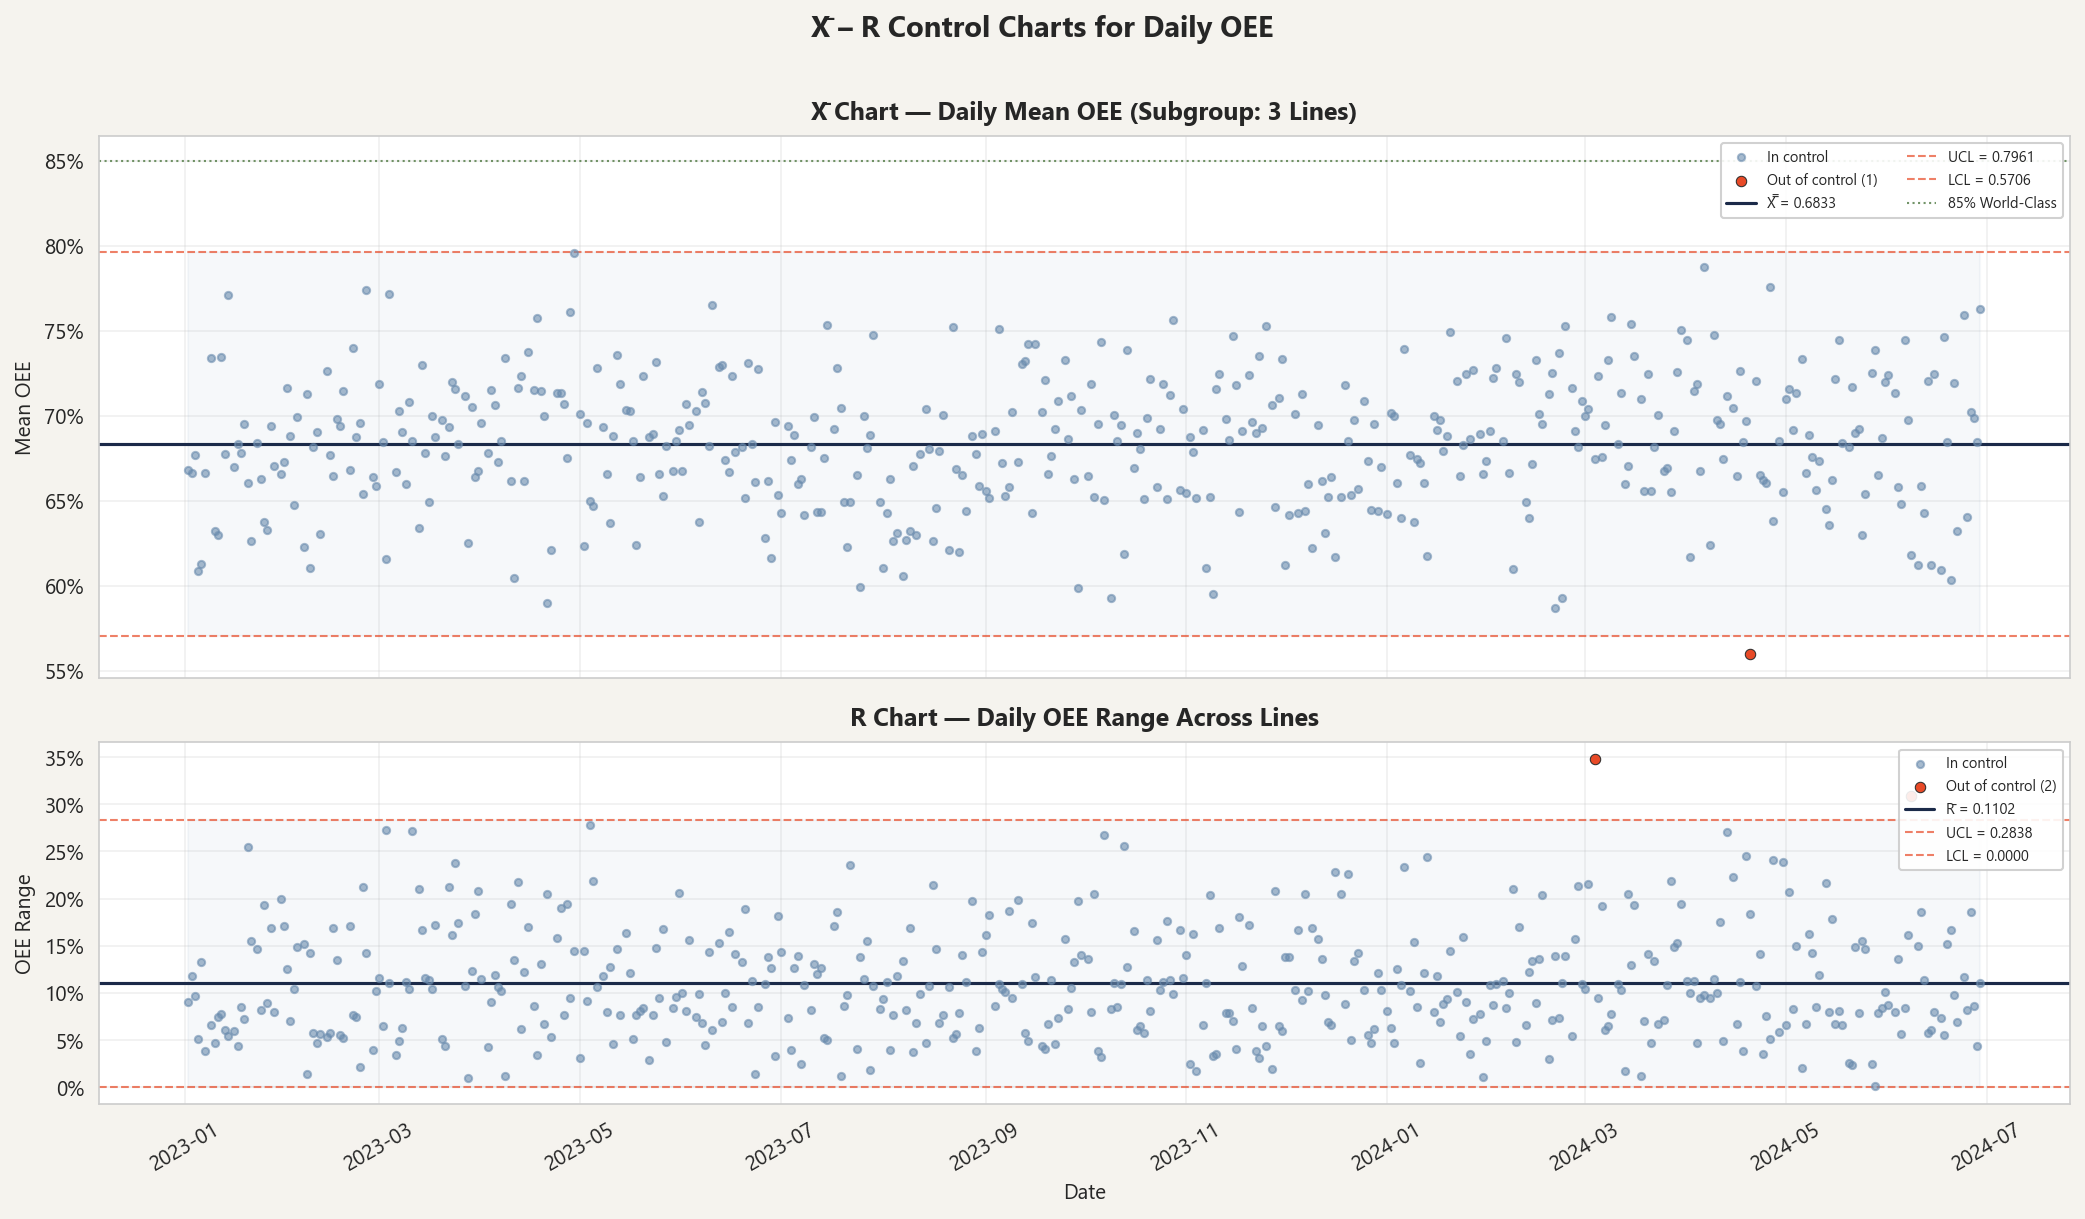

In [10]:
# ── X-bar & R Chart (stacked) ───────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                gridspec_kw={"height_ratios": [3, 2]})

dates = daily_oee_full["production_date"]

# ── X-bar Chart (top) ──────────────────────────────────────────────
mask_xb = daily_oee_full["x_bar_ooc"]

ax1.scatter(dates[~mask_xb], daily_oee_full.loc[~mask_xb, "x_bar"],
            color=IN_CTRL, s=12, alpha=0.6, zorder=3, label="In control")
ax1.scatter(dates[mask_xb], daily_oee_full.loc[mask_xb, "x_bar"],
            color=OUT_CTRL, s=25, edgecolors=CHARCOAL, linewidths=0.5,
            zorder=4, label=f"Out of control ({mask_xb.sum()})")

ax1.axhline(x_bar_bar, color=CL_COLOR, linewidth=1.5, label=f"X̿ = {x_bar_bar:.4f}")
ax1.axhline(x_bar_UCL, color=UCL_COLOR, linewidth=1, linestyle="--", alpha=0.7,
            label=f"UCL = {x_bar_UCL:.4f}")
ax1.axhline(x_bar_LCL, color=LCL_COLOR, linewidth=1, linestyle="--", alpha=0.7,
            label=f"LCL = {x_bar_LCL:.4f}")
ax1.fill_between(dates, x_bar_LCL, x_bar_UCL, alpha=0.06, color=STEEL)

# 85% world-class benchmark
ax1.axhline(0.85, color=SAGE, linewidth=1, linestyle=":", alpha=0.8, label="85% World-Class")

ax1.set_title("X̄ Chart — Daily Mean OEE (Subgroup: 3 Lines)", fontsize=12, pad=8)
ax1.set_ylabel("Mean OEE")
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax1.legend(loc="upper right", fontsize=7, framealpha=0.9, ncol=2)

# ── R Chart (bottom) ──────────────────────────────────────────────
mask_r = daily_oee_full["r_ooc"]

ax2.scatter(dates[~mask_r], daily_oee_full.loc[~mask_r, "r"],
            color=IN_CTRL, s=12, alpha=0.6, zorder=3, label="In control")
ax2.scatter(dates[mask_r], daily_oee_full.loc[mask_r, "r"],
            color=OUT_CTRL, s=25, edgecolors=CHARCOAL, linewidths=0.5,
            zorder=4, label=f"Out of control ({mask_r.sum()})")

ax2.axhline(r_bar, color=CL_COLOR, linewidth=1.5, label=f"R̄ = {r_bar:.4f}")
ax2.axhline(r_UCL, color=UCL_COLOR, linewidth=1, linestyle="--", alpha=0.7,
            label=f"UCL = {r_UCL:.4f}")
ax2.axhline(r_LCL, color=LCL_COLOR, linewidth=1, linestyle="--", alpha=0.7,
            label=f"LCL = {r_LCL:.4f}")
ax2.fill_between(dates, r_LCL, r_UCL, alpha=0.06, color=STEEL)

ax2.set_title("R Chart — Daily OEE Range Across Lines", fontsize=12, pad=8)
ax2.set_xlabel("Date")
ax2.set_ylabel("OEE Range")
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax2.legend(loc="upper right", fontsize=7, framealpha=0.9)

ax2.tick_params(axis="x", rotation=30)
fig.suptitle("X̄ – R Control Charts for Daily OEE", fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

### X̄ – R Chart Interpretation

| Chart | Center Line | UCL | LCL | OOC Points | Verdict |
|-------|-------------|-----|-----|------------|---------|
| X̄ (mean OEE) | 68.33% | 79.61% | 57.06% | 1 / 468 | ✅ In control |
| R (OEE range) | 11.02% | 28.38% | 0.00% | 2 / 468 | ✅ In control |

**Key insight — the most important finding in this notebook:**

| Process | In Statistical Control? | Problem Type | Improvement Strategy |
|---------|------------------------|--------------|---------------------|
| **Defect Rate (p-chart)** | ❌ No — 73 OOC points | **Unstable** — assignable causes | Identify and eliminate special causes (DMAIC Analyze) |
| **OEE (X̄-R chart)** | ✅ Yes — 3 OOC points | **Stable but poorly centered** | Shift the process mean upward (system-level changes) |

**What this means for LumenTech BV:**
- **Quality:** Don't tighten targets yet. First, investigate the 73 out-of-control days to remove assignable causes. Only after the process is stable can you meaningfully reduce p̄.
- **OEE:** The process IS predictable — it will keep delivering ~68% OEE unless the system changes. The 85% world-class gap (16.7 percentage points) requires structural intervention: reducing changeover time, addressing chronic understaffing, and debottlenecking Line_C.

This is textbook SPC: **control first, then capability.**

**Next:** I-MR chart for individual daily defect rate — a complementary view when subgroup size = 1.

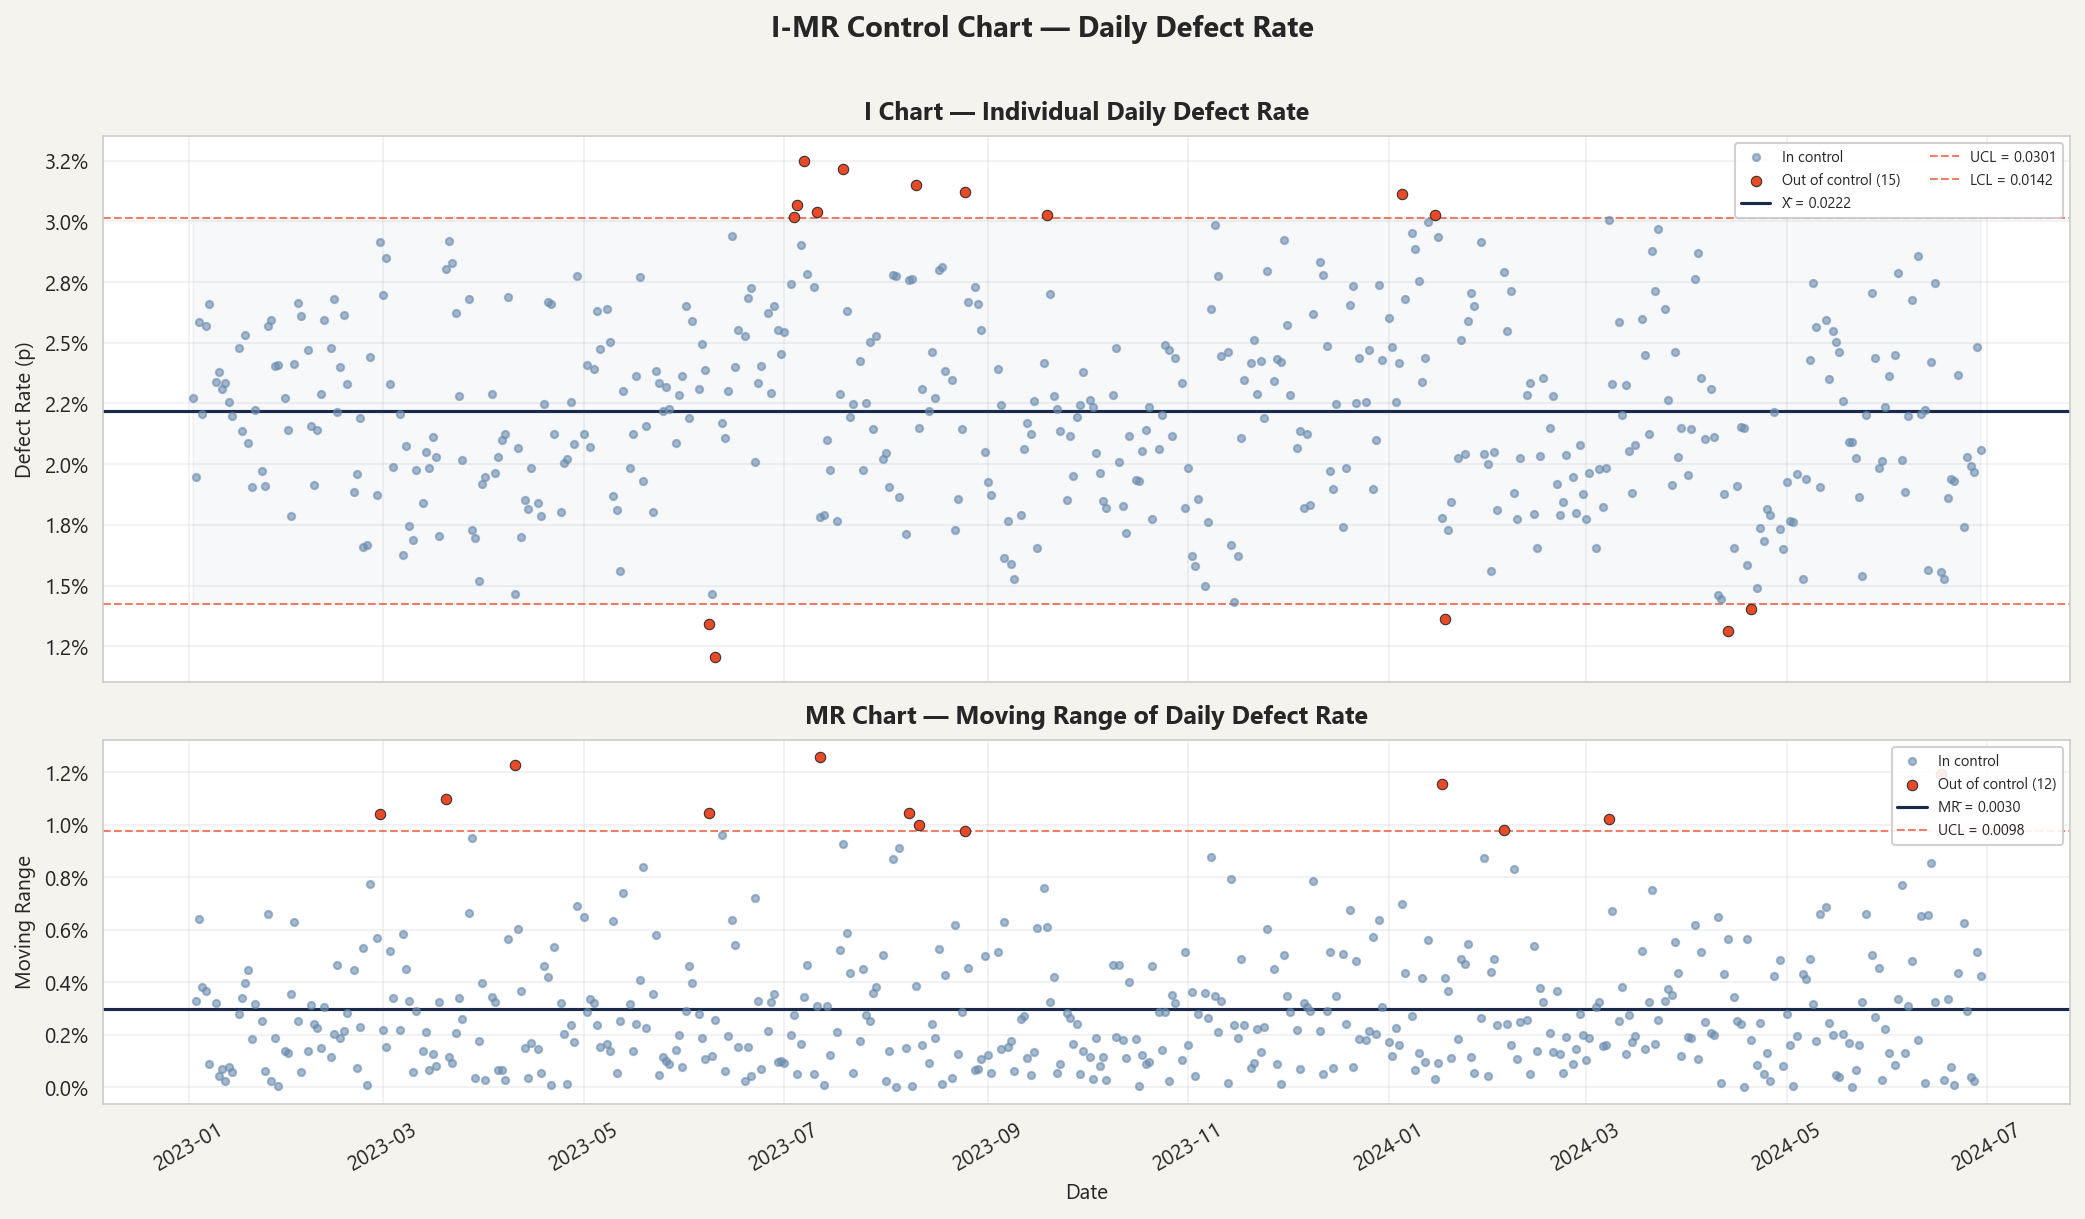


── I Chart ──
X̄: 0.0222  |  UCL: 0.0301  |  LCL: 0.0142
σ̂ (from MR): 0.0026
Out-of-control: 15 / 468

── MR Chart ──
MR̄: 0.0030  |  UCL: 0.0098
Out-of-control: 12 / 467


In [11]:
# ── I-MR Chart: Individual daily defect rate + Moving Range ─────────
# Uses daily_qc["p"] from Cell 4 (individual observations, no subgrouping)

daily_qc = daily_qc.sort_values("inspected_date").reset_index(drop=True)

# Moving Range (consecutive differences)
daily_qc["MR"] = daily_qc["p"].diff().abs()

# Constants for n=2 (moving range of 2 consecutive points)
d2 = 1.128   # E(R) = d2 * σ → σ̂ = R̄/d2
D4_mr = 3.267

# Center lines
p_mean = daily_qc["p"].mean()
mr_bar = daily_qc["MR"].mean()
sigma_hat = mr_bar / d2

# I-chart limits
i_UCL = p_mean + 3 * sigma_hat
i_LCL = max(0, p_mean - 3 * sigma_hat)

# MR-chart limits
mr_UCL = D4_mr * mr_bar
mr_LCL = 0

# Flag OOC
daily_qc["i_ooc"] = (daily_qc["p"] > i_UCL) | (daily_qc["p"] < i_LCL)
daily_qc["mr_ooc"] = daily_qc["MR"] > mr_UCL

# ── Plot ────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                gridspec_kw={"height_ratios": [3, 2]})

dates = daily_qc["inspected_date"]

# ── I Chart (top) ──────────────────────────────────────────────────
mask_i = daily_qc["i_ooc"]
ax1.scatter(dates[~mask_i], daily_qc.loc[~mask_i, "p"],
            color=IN_CTRL, s=12, alpha=0.6, zorder=3, label="In control")
ax1.scatter(dates[mask_i], daily_qc.loc[mask_i, "p"],
            color=OUT_CTRL, s=25, edgecolors=CHARCOAL, linewidths=0.5,
            zorder=4, label=f"Out of control ({mask_i.sum()})")

ax1.axhline(p_mean, color=CL_COLOR, linewidth=1.5, label=f"X̄ = {p_mean:.4f}")
ax1.axhline(i_UCL, color=UCL_COLOR, linewidth=1, linestyle="--", alpha=0.7,
            label=f"UCL = {i_UCL:.4f}")
ax1.axhline(i_LCL, color=LCL_COLOR, linewidth=1, linestyle="--", alpha=0.7,
            label=f"LCL = {i_LCL:.4f}")
ax1.fill_between(dates, i_LCL, i_UCL, alpha=0.06, color=STEEL)

ax1.set_title("I Chart — Individual Daily Defect Rate", fontsize=12, pad=8)
ax1.set_ylabel("Defect Rate (p)")
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
ax1.legend(loc="upper right", fontsize=7, framealpha=0.9, ncol=2)

# ── MR Chart (bottom) ─────────────────────────────────────────────
mask_mr = daily_qc["mr_ooc"].fillna(False)
mr_dates = dates[1:]  # MR starts from 2nd observation
mr_vals = daily_qc["MR"].iloc[1:]
mask_mr_plot = mask_mr.iloc[1:]

ax2.scatter(mr_dates[~mask_mr_plot], mr_vals[~mask_mr_plot],
            color=IN_CTRL, s=12, alpha=0.6, zorder=3, label="In control")
ax2.scatter(mr_dates[mask_mr_plot], mr_vals[mask_mr_plot],
            color=OUT_CTRL, s=25, edgecolors=CHARCOAL, linewidths=0.5,
            zorder=4, label=f"Out of control ({mask_mr_plot.sum()})")

ax2.axhline(mr_bar, color=CL_COLOR, linewidth=1.5, label=f"MR̄ = {mr_bar:.4f}")
ax2.axhline(mr_UCL, color=UCL_COLOR, linewidth=1, linestyle="--", alpha=0.7,
            label=f"UCL = {mr_UCL:.4f}")

ax2.set_title("MR Chart — Moving Range of Daily Defect Rate", fontsize=12, pad=8)
ax2.set_xlabel("Date")
ax2.set_ylabel("Moving Range")
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
ax2.legend(loc="upper right", fontsize=7, framealpha=0.9)

ax2.tick_params(axis="x", rotation=30)
fig.suptitle("I-MR Control Chart — Daily Defect Rate", fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

print(f"\n── I Chart ──")
print(f"X̄: {p_mean:.4f}  |  UCL: {i_UCL:.4f}  |  LCL: {i_LCL:.4f}")
print(f"σ̂ (from MR): {sigma_hat:.4f}")
print(f"Out-of-control: {mask_i.sum()} / {len(daily_qc)}")
print(f"\n── MR Chart ──")
print(f"MR̄: {mr_bar:.4f}  |  UCL: {mr_UCL:.4f}")
print(f"Out-of-control: {mask_mr_plot.sum()} / {len(mr_vals)}")

### I-MR Chart Interpretation

| Chart | Center Line | UCL | LCL | OOC | Verdict |
|-------|-------------|-----|-----|-----|---------|
| I (individual defect rate) | 2.22% | 3.01% | 1.42% | 15 / 468 | ❌ Out of control |
| MR (moving range) | 0.30% | 0.98% | — | 12 / 467 | ❌ Out of control |

**Three methods, one conclusion:**

| Chart Type | σ Estimation | OOC Points | Sensitivity |
|------------|-------------|------------|-------------|
| p-chart | Binomial (√p̄q̄/n) | 73 (15.6%) | Most sensitive — recommended for attribute data |
| np-chart | Constant n̄ | 170 (36.3%) | Overstates — inappropriate for variable sample sizes |
| I-MR | Moving range (MR̄/d2) | 15 (3.2%) | Most conservative — absorbs between-day noise |

All three confirm the defect rate process is **not in statistical control.** The p-chart is the statistically correct choice for this data (attribute data, variable sample size) and will be the primary reference in the project documentation.

**Next:** Investigate what drives out-of-control days — which defect types and conditions correlate with OOC signals?

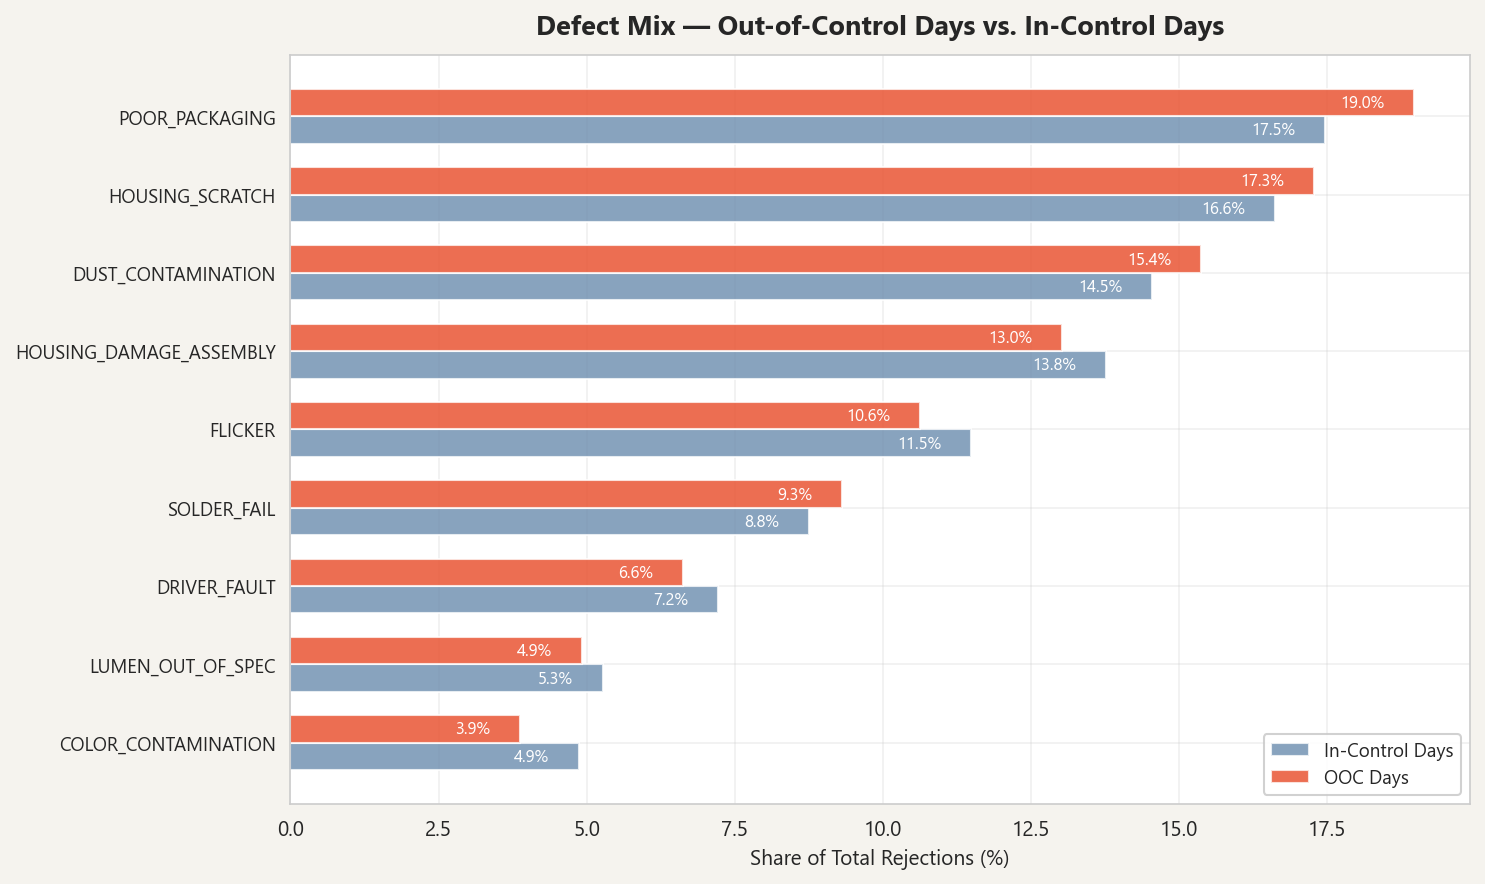


Defect mix comparison (% of rejections within group):

is_ooc_day               In Control  OOC Days
defect_reason                                
POOR_PACKAGING                 17.5      19.0
HOUSING_SCRATCH                16.6      17.3
DUST_CONTAMINATION             14.5      15.4
HOUSING_DAMAGE_ASSEMBLY        13.8      13.0
FLICKER                        11.5      10.6
SOLDER_FAIL                     8.8       9.3
DRIVER_FAULT                    7.2       6.6
LUMEN_OUT_OF_SPEC               5.3       4.9
COLOR_CONTAMINATION             4.9       3.9

── Day counts ──
OOC days: 73  |  In-control days: 395


In [12]:
# ── Investigate out-of-control days from p-chart ────────────────────
# Merge OOC flags back to raw QC data
ooc_dates = daily_qc.loc[daily_qc["out_of_control"], "inspected_date"].values
qc["is_ooc_day"] = qc["inspected_date"].isin(ooc_dates)

# ── Defect mix: OOC days vs. in-control days ────────────────────────
defect_comparison = (
    qc[qc["units_rejected"] > 0]
    .groupby(["is_ooc_day", "defect_reason"])
    .agg(total_rejects=("units_rejected", "sum"))
    .reset_index()
)

# Pivot for side-by-side comparison
defect_pivot = defect_comparison.pivot_table(
    index="defect_reason", columns="is_ooc_day",
    values="total_rejects", fill_value=0
).rename(columns={False: "In Control", True: "OOC Days"})

# Normalize to percentages within each group
defect_pct = defect_pivot.div(defect_pivot.sum()) * 100
defect_pct = defect_pct.sort_values("OOC Days", ascending=False)

# ── Plot ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(defect_pct))
width = 0.35

bars1 = ax.barh(x + width/2, defect_pct["In Control"], width,
                color=STEEL, alpha=0.8, label="In-Control Days")
bars2 = ax.barh(x - width/2, defect_pct["OOC Days"], width,
                color=EMBER, alpha=0.8, label="OOC Days")

ax.set_yticks(x)
ax.set_yticklabels(defect_pct.index, fontsize=9)
ax.set_xlabel("Share of Total Rejections (%)")
ax.set_title("Defect Mix — Out-of-Control Days vs. In-Control Days", fontsize=13, pad=10)
ax.legend(loc="lower right", fontsize=9, framealpha=0.9)
ax.invert_yaxis()

# Add percentage labels
for bar_group in [bars1, bars2]:
    for bar in bar_group:
        w = bar.get_width()
        if w > 2:
            ax.text(w - 0.5, bar.get_y() + bar.get_height()/2,
                    f"{w:.1f}%", ha="right", va="center", fontsize=8, color="white")

fig.tight_layout()
plt.show()

# ── Print the comparison table ──────────────────────────────────────
print("\nDefect mix comparison (% of rejections within group):\n")
print(defect_pct.round(1).to_string())
print(f"\n── Day counts ──")
print(f"OOC days: {daily_qc['out_of_control'].sum()}  |  In-control days: {(~daily_qc['out_of_control']).sum()}")

In [13]:
# ── Compare operational conditions: OOC days vs. in-control days ────
# Load production log data for the same dates
prod = con.execute("""
    SELECT 
        production_date,
        line_id,
        actual_operators,
        planned_operators,
        downtime_mins,
        downtime_reason,
        overtime_hours,
        actual_units,
        planned_units
    FROM main_staging.stg_production_log
""").fetchdf()

prod["fill_rate"] = prod["actual_operators"] / prod["planned_operators"]
prod["is_ooc_day"] = prod["production_date"].isin(ooc_dates)

# ── Aggregate operational metrics by OOC status ─────────────────────
ops_compare = (
    prod.groupby("is_ooc_day")
    .agg(
        avg_fill_rate=("fill_rate", "mean"),
        avg_downtime=("downtime_mins", "mean"),
        avg_overtime=("overtime_hours", "mean"),
        pct_changeover=("downtime_reason", lambda x: (x == "CHANGEOVER").mean() * 100),
        pct_manpower=("downtime_reason", lambda x: (x == "MANPOWER_SHORT").mean() * 100),
        avg_plan_adherence=("actual_units", lambda x: (x / prod.loc[x.index, "planned_units"]).mean() * 100),
    )
    .rename(index={False: "In-Control Days", True: "OOC Days"})
)

print("Operational conditions — OOC vs. In-Control days:\n")
print(ops_compare.round(2).T.to_string())

# ── Statistical significance (quick Mann-Whitney U) ─────────────────
from scipy.stats import mannwhitneyu

fill_ooc = prod.loc[prod["is_ooc_day"], "fill_rate"].dropna()
fill_ic = prod.loc[~prod["is_ooc_day"], "fill_rate"].dropna()

dt_ooc = prod.loc[prod["is_ooc_day"], "downtime_mins"].dropna()
dt_ic = prod.loc[~prod["is_ooc_day"], "downtime_mins"].dropna()

print("\n── Mann-Whitney U Tests ──")
for label, ooc_vals, ic_vals in [("Staffing Fill Rate", fill_ooc, fill_ic),
                                   ("Downtime (mins)", dt_ooc, dt_ic)]:
    stat, pval = mannwhitneyu(ooc_vals, ic_vals, alternative="two-sided")
    sig = "✅ Significant" if pval < 0.05 else "❌ Not significant"
    print(f"{label}: U={stat:.0f}, p={pval:.4f} → {sig}")

Operational conditions — OOC vs. In-Control days:

is_ooc_day          In-Control Days  OOC Days
avg_fill_rate                  0.83      0.82
avg_downtime                  65.98     62.14
avg_overtime                   1.42      1.36
pct_changeover                15.62     15.62
pct_manpower                  16.13     17.95
avg_plan_adherence            81.35     81.79

── Mann-Whitney U Tests ──
Staffing Fill Rate: U=420639, p=0.0040 → ✅ Significant
Downtime (mins): U=440760, p=0.1687 → ❌ Not significant


### Out-of-Control Day Investigation

**Question:** What drives the 73 out-of-control days flagged by the p-chart?

**Finding 1 — Defect mix is unchanged.** The ranking and proportional share of defect types is virtually identical between OOC and in-control days. No single defect type "spikes" — on bad days, everything gets worse proportionally. This rules out a single-failure-mode explanation.

**Finding 2 — Operational conditions show marginal differences.**

| Metric | In-Control Days | OOC Days | Δ |
|--------|----------------|----------|---|
| Staffing fill rate | 0.83 | 0.82 | −0.01 (p=0.004 ✅) |
| Avg downtime (mins) | 65.98 | 62.14 | Not significant |
| MANPOWER_SHORT frequency | 16.1% | 18.0% | +11% relative |
| Plan adherence | 81.4% | 81.8% | Negligible |

**Interpretation:** Quality instability is a **compound effect** — marginally worse staffing, slightly more manpower stoppages, and likely material batch variation (not directly observable in this dataset). No single operational lever explains the OOC signals in isolation.

**Implication for LumenTech BV:** The root cause investigation for quality instability should focus on **interaction effects** — the combination of understaffing + changeovers + specific material batches — rather than hunting for one smoking gun. This is a strong candidate for a designed experiment (DOE) or multivariate analysis in the next phase.

**Next:** Western Electric rules — supplementary pattern detection beyond the basic 3σ test.

In [14]:
# ── Western Electric Rules on p-chart data ──────────────────────────
# Applied to daily defect rate (daily_qc["p"])
# Rules detect non-random patterns even within control limits

p_vals = daily_qc["p"].values
sigma = np.sqrt(p_bar * (1 - p_bar) / daily_qc["total_inspected"].values)

# Standardize: how many σ from p̄?
z = (p_vals - p_bar) / sigma

n = len(z)

# ── Rule 1: 1 point beyond 3σ (already have this from p-chart) ─────
rule1 = np.abs(z) > 3

# ── Rule 2: 2 of 3 consecutive points beyond 2σ (same side) ────────
rule2 = np.zeros(n, dtype=bool)
for i in range(2, n):
    window = z[i-2:i+1]
    above_2s = np.sum(window > 2)
    below_2s = np.sum(window < -2)
    if above_2s >= 2 or below_2s >= 2:
        rule2[i] = True

# ── Rule 3: 4 of 5 consecutive points beyond 1σ (same side) ────────
rule3 = np.zeros(n, dtype=bool)
for i in range(4, n):
    window = z[i-4:i+1]
    above_1s = np.sum(window > 1)
    below_1s = np.sum(window < -1)
    if above_1s >= 4 or below_1s >= 4:
        rule3[i] = True

# ── Rule 4: 8 consecutive points on same side of center line ───────
rule4 = np.zeros(n, dtype=bool)
for i in range(7, n):
    window = z[i-7:i+1]
    if np.all(window > 0) or np.all(window < 0):
        rule4[i] = True

# ── Summary ─────────────────────────────────────────────────────────
any_violation = rule1 | rule2 | rule3 | rule4

results = pd.DataFrame({
    "Rule": [
        "Rule 1: 1 point beyond 3σ",
        "Rule 2: 2 of 3 beyond 2σ (same side)",
        "Rule 3: 4 of 5 beyond 1σ (same side)",
        "Rule 4: 8 consecutive same side",
    ],
    "Violations": [rule1.sum(), rule2.sum(), rule3.sum(), rule4.sum()],
    "% of Days": [f"{x/n*100:.1f}%" for x in [rule1.sum(), rule2.sum(), rule3.sum(), rule4.sum()]],
})

print("Western Electric Rules — Defect Rate p-Chart\n")
print(results.to_string(index=False))
print(f"\nTotal days with ANY violation: {any_violation.sum()} / {n} ({any_violation.mean()*100:.1f}%)")
print(f"Days with NO violations:      {(~any_violation).sum()} / {n} ({(~any_violation).mean()*100:.1f}%)")

# Store for plotting
daily_qc["rule1"] = rule1
daily_qc["rule2"] = rule2
daily_qc["rule3"] = rule3
daily_qc["rule4"] = rule4
daily_qc["any_we_violation"] = any_violation

Western Electric Rules — Defect Rate p-Chart

                                Rule  Violations % of Days
           Rule 1: 1 point beyond 3σ          73     15.6%
Rule 2: 2 of 3 beyond 2σ (same side)         135     28.8%
Rule 3: 4 of 5 beyond 1σ (same side)         111     23.7%
     Rule 4: 8 consecutive same side          51     10.9%

Total days with ANY violation: 231 / 468 (49.4%)
Days with NO violations:      237 / 468 (50.6%)


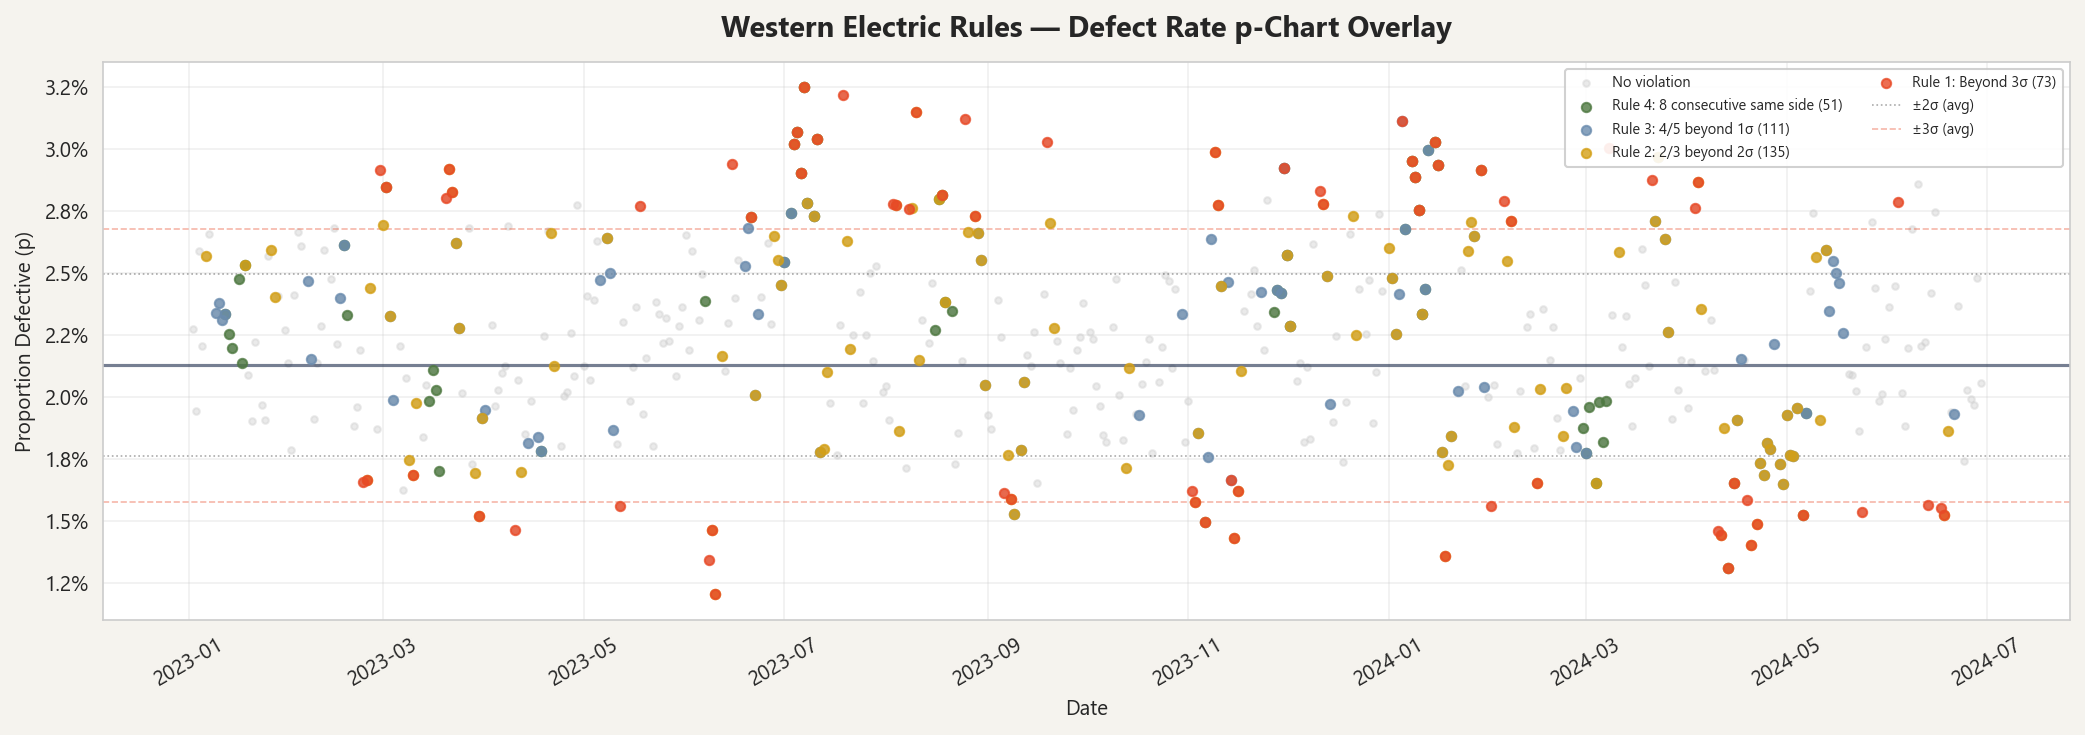

In [15]:
# ── WE Rules overlay on p-chart ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

dates = daily_qc["inspected_date"]

# Base: all points in grey
ax.scatter(dates, daily_qc["p"], color="#CCCCCC", s=10, alpha=0.4, zorder=2, label="No violation")

# Layer violations by rule (most severe on top)
colors = {
    "rule4": (SAGE, "Rule 4: 8 consecutive same side"),
    "rule3": (STEEL, "Rule 3: 4/5 beyond 1σ"),
    "rule2": ("#D4A017", "Rule 2: 2/3 beyond 2σ"),
    "rule1": (EMBER, "Rule 1: Beyond 3σ"),
}

for rule_col, (color, label) in colors.items():
    mask = daily_qc[rule_col]
    if mask.sum() > 0:
        ax.scatter(dates[mask], daily_qc.loc[mask, "p"],
                   color=color, s=20, alpha=0.8, zorder=3, label=f"{label} ({mask.sum()})")

# Control lines
ax.axhline(p_bar, color=CL_COLOR, linewidth=1.5, linestyle="-", alpha=0.6)
ax.axhline(p_bar + 2*np.sqrt(p_bar*(1-p_bar)/n_bar), color=CHARCOAL,
           linewidth=0.8, linestyle=":", alpha=0.4, label="±2σ (avg)")
ax.axhline(p_bar - 2*np.sqrt(p_bar*(1-p_bar)/n_bar), color=CHARCOAL,
           linewidth=0.8, linestyle=":", alpha=0.4)
ax.axhline(p_bar + 3*np.sqrt(p_bar*(1-p_bar)/n_bar), color=UCL_COLOR,
           linewidth=0.8, linestyle="--", alpha=0.4, label="±3σ (avg)")
ax.axhline(p_bar - 3*np.sqrt(p_bar*(1-p_bar)/n_bar), color=LCL_COLOR,
           linewidth=0.8, linestyle="--", alpha=0.4)

ax.set_title("Western Electric Rules — Defect Rate p-Chart Overlay", fontsize=14, pad=12)
ax.set_xlabel("Date")
ax.set_ylabel("Proportion Defective (p)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
ax.legend(loc="upper right", fontsize=7, framealpha=0.9, ncol=2)
ax.tick_params(axis="x", rotation=30)

fig.tight_layout()
plt.show()

### Western Electric Rules — Supplementary Pattern Detection

| Rule | Description | Violations | % of Days |
|------|------------|------------|-----------|
| Rule 1 | 1 point beyond 3σ | 73 | 15.6% |
| Rule 2 | 2 of 3 consecutive beyond 2σ (same side) | 135 | 28.8% |
| Rule 3 | 4 of 5 consecutive beyond 1σ (same side) | 111 | 23.7% |
| Rule 4 | 8 consecutive points same side of CL | 51 | 10.9% |
| **Any rule** | **At least one violation** | **231** | **49.4%** |

**Key observations:**
1. **Rule 2 dominates (135 days):** The process frequently clusters near 2σ on one side — indicating short-term shifts lasting 2–3 days. This pattern is consistent with batch-level variation (a bad material delivery, a temporary staffing change) causing multi-day quality dips.
2. **Rule 4 confirms drift (51 days):** Runs of 8+ days on one side of p̄ mean the process mean is shifting — not just experiencing random spikes. This is the SPC signature of assignable causes that persist for days before reverting.
3. **No seasonal pattern:** Violations are scattered across all 18 months, ruling out a time-dependent root cause (e.g., summer shutdowns, seasonal demand). The instability is structural, not periodic.
4. **Nearly half of all days (49.4%) violate at least one rule** — reinforcing the p-chart verdict: this process needs to be stabilized before capability targets are meaningful.

**Next:** Process Capability analysis — quantifying how far the process is from meeting specification limits.

In [16]:
# ── Process Capability — Defect Rate ────────────────────────────────
# Specification: FPY target ≥ 97% → max allowable defect rate = 3%
# Using daily defect rate (daily_qc["p"]) as the process output

USL = 0.03   # Upper Spec Limit: 3% defect rate (= 97% FPY target)
LSL = 0.0    # Lower Spec Limit: 0% defects (theoretical best)

p_mean = daily_qc["p"].mean()
p_std = daily_qc["p"].std()

# ── Cp: Process potential (spread vs spec width) ────────────────────
Cp = (USL - LSL) / (6 * p_std)

# ── Cpk: Process capability (centering + spread) ───────────────────
Cpu = (USL - p_mean) / (3 * p_std)  # Upper capability
Cpl = (p_mean - LSL) / (3 * p_std)  # Lower capability
Cpk = min(Cpu, Cpl)

# ── Pp/Ppk (same formula but using overall σ, not within-group) ────
# For individual data, Pp = Cp and Ppk = Cpk — included for completeness
Pp = Cp
Ppk = Cpk

# ── Sigma level ─────────────────────────────────────────────────────
from scipy.stats import norm
if Cpk > 0:
    sigma_level = 3 * Cpk
    ppm_expected = norm.sf(sigma_level) * 1_000_000  # Parts per million above USL
else:
    sigma_level = 0
    ppm_expected = 500_000

print("Process Capability — Daily Defect Rate")
print(f"{'='*50}")
print(f"USL (max defect rate):  {USL*100:.1f}%  (= 97% FPY target)")
print(f"LSL:                    {LSL*100:.1f}%")
print(f"Process mean (p̄):      {p_mean*100:.2f}%")
print(f"Process σ:              {p_std*100:.2f}%")
print(f"\n{'── Capability Indices ──':}")
print(f"Cp  (potential):   {Cp:.3f}    {'✅ ≥ 1.33' if Cp >= 1.33 else '❌ < 1.33'}")
print(f"Cpk (actual):      {Cpk:.3f}    {'✅ ≥ 1.33' if Cpk >= 1.33 else '❌ < 1.33'}")
print(f"Cpu (upper):       {Cpu:.3f}")
print(f"Cpl (lower):       {Cpl:.3f}")
print(f"\n{'── Sigma Level ──':}")
print(f"Process sigma:     {sigma_level:.2f}σ")
print(f"Expected PPM > USL: {ppm_expected:,.0f}")
print(f"\n{'── Interpretation ──':}")
if Cpk >= 1.33:
    print("Process is CAPABLE — meets Six Sigma minimum threshold.")
elif Cpk >= 1.0:
    print("Process is MARGINALLY CAPABLE — meets spec but with little margin.")
else:
    print("Process is NOT CAPABLE — cannot reliably meet the 97% FPY target.")

Process Capability — Daily Defect Rate
USL (max defect rate):  3.0%  (= 97% FPY target)
LSL:                    0.0%
Process mean (p̄):      2.22%
Process σ:              0.39%

── Capability Indices ──
Cp  (potential):   1.284    ❌ < 1.33
Cpk (actual):      0.669    ❌ < 1.33
Cpu (upper):       0.669
Cpl (lower):       1.898

── Sigma Level ──
Process sigma:     2.01σ
Expected PPM > USL: 22,322

── Interpretation ──
Process is NOT CAPABLE — cannot reliably meet the 97% FPY target.


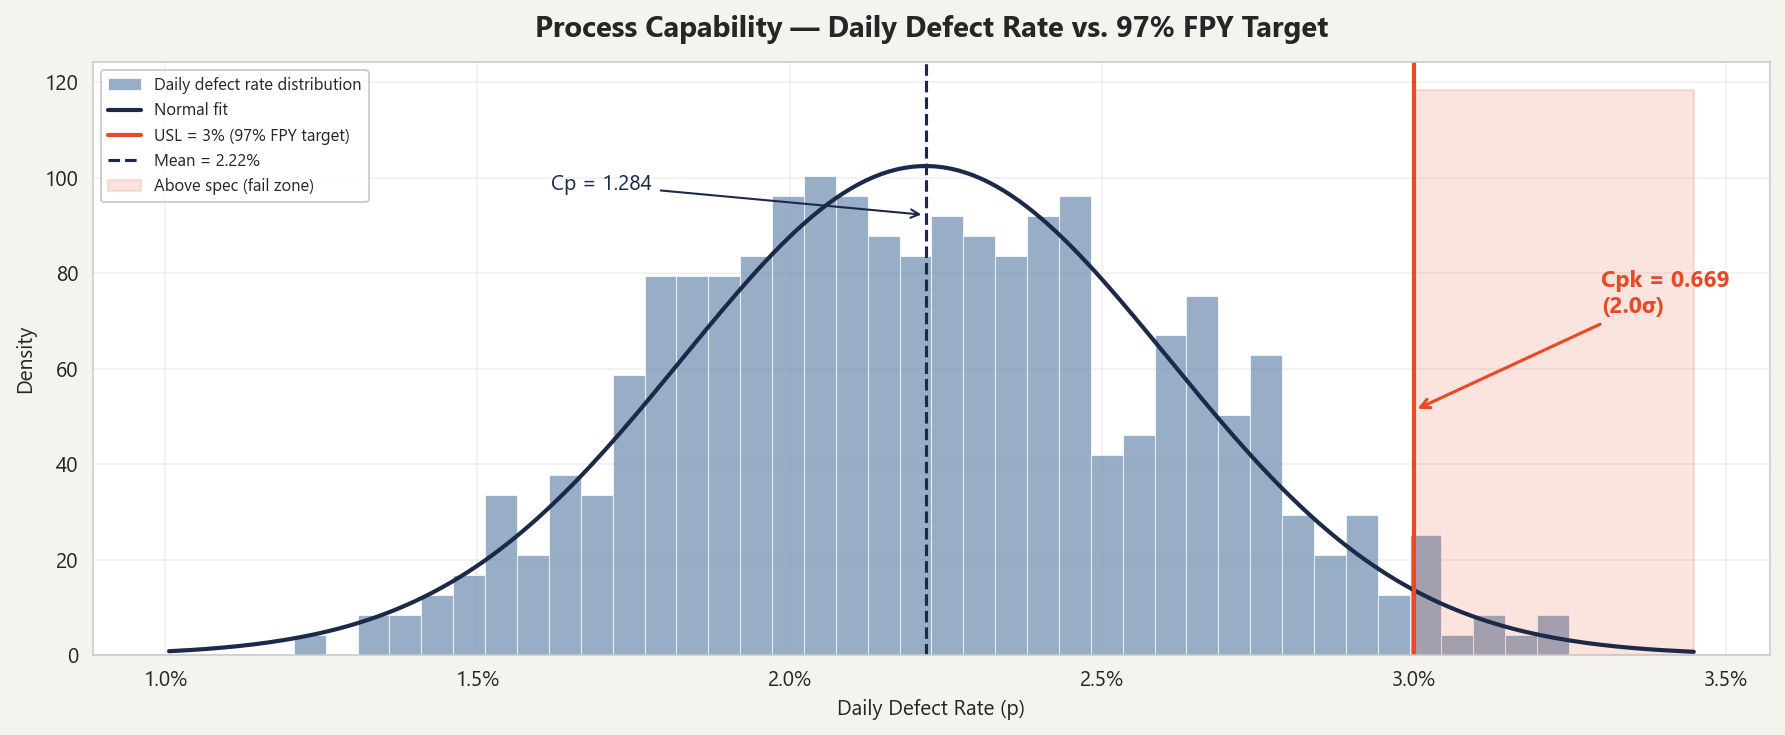

In [17]:
# ── Capability histogram with spec limits ───────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

# Histogram of daily defect rate
counts, bins, patches = ax.hist(daily_qc["p"], bins=40, color=STEEL, alpha=0.7,
                                 edgecolor="white", linewidth=0.5, density=True,
                                 label="Daily defect rate distribution")

# Normal curve overlay
x_range = np.linspace(daily_qc["p"].min() - 0.002, daily_qc["p"].max() + 0.002, 200)
normal_curve = norm.pdf(x_range, p_mean, p_std)
ax.plot(x_range, normal_curve, color=NAVY, linewidth=2, label="Normal fit")

# Spec limits
ax.axvline(USL, color=EMBER, linewidth=2, linestyle="-", label=f"USL = {USL*100:.0f}% (97% FPY target)")
ax.axvline(p_mean, color=CL_COLOR, linewidth=1.5, linestyle="--", label=f"Mean = {p_mean*100:.2f}%")

# Shade the "fail" region
ax.fill_betweenx([0, ax.get_ylim()[1]*1.1], USL, x_range[-1],
                  alpha=0.15, color=EMBER, label="Above spec (fail zone)")

# Annotations
ax.annotate(f"Cpk = {Cpk:.3f}\n({sigma_level:.1f}σ)",
            xy=(USL, max(normal_curve)*0.5), xytext=(USL + 0.003, max(normal_curve)*0.7),
            fontsize=11, fontweight="bold", color=EMBER,
            arrowprops=dict(arrowstyle="->", color=EMBER, lw=1.5))

ax.annotate(f"Cp = {Cp:.3f}",
            xy=(p_mean, max(normal_curve)*0.9), xytext=(p_mean - 0.006, max(normal_curve)*0.95),
            fontsize=10, color=NAVY,
            arrowprops=dict(arrowstyle="->", color=NAVY, lw=1))

ax.set_title("Process Capability — Daily Defect Rate vs. 97% FPY Target", fontsize=14, pad=12)
ax.set_xlabel("Daily Defect Rate (p)")
ax.set_ylabel("Density")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
ax.legend(loc="upper left", fontsize=8, framealpha=0.9)

fig.tight_layout()
plt.show()

### Process Capability Interpretation

| Index | Value | Threshold | Verdict |
|-------|-------|-----------|---------|
| Cp (potential) | 1.284 | ≥ 1.33 | ❌ Slightly below — spread almost fits spec |
| Cpk (actual) | 0.669 | ≥ 1.33 | ❌ Badly off-center — shifted toward USL |
| Sigma level | 2.01σ | ≥ 4σ (industry min) | ❌ Only 2σ — ~22,322 PPM above spec |

**The Cp vs. Cpk gap is the key diagnostic:**
- **Cp = 1.284** → The process variation (6σ spread) is 96% of the spec width. If perfectly centered, it would *nearly* be capable.
- **Cpk = 0.669** → But the process mean (2.22%) is shifted toward the USL (3.0%), eating up the margin. The tail bleeds past the spec limit.

**Two-step improvement path:**
1. **Center the process (address Cpk):** Reduce the mean defect rate from 2.22% toward 1.50% — this alone would lift Cpk above 1.0. Requires eliminating assignable causes identified by the p-chart (the 73 OOC days).
2. **Tighten the spread (address Cp):** Reduce day-to-day variation (σ from 0.39% toward 0.28%) to push Cp above 1.33. Requires standardizing operations — consistent staffing, stable schedules, controlled material batches.

**Business framing:** At 2.01σ, LumenTech produces ~22,000 defective units per million opportunities above the FPY target. For a plant producing ~6,200 inspected units/day, that means roughly **14 days per year** will exceed the acceptable defect threshold — each one a candidate for customer complaints, rework costs, and delivery delays.

## SPC Notebook Summary — Key Findings & Recommendations

### The Three Verdicts

| Process | In Control? | Capable? | Priority |
|---------|-------------|----------|----------|
| Defect rate (p-chart) | ❌ No — 73 OOC days (15.6%) | ❌ No — Cpk = 0.669 | 🔴 High — stabilize first |
| OEE (X̄-R chart) | ✅ Yes — 3 OOC days (0.6%) | N/A — stable but centered at 68% | 🟡 Medium — shift the mean |

### The SPC Principle Applied

**Control before capability. Capability before targets.**

LumenTech's quality process violates this sequence — leadership is chasing a 97% FPY target on a process that isn't even in statistical control. The correct sequence:

1. **Phase 1 — Stabilize:** Investigate and eliminate the assignable causes behind 73 OOC days. Focus on the compound effect of understaffing + changeovers + material batch variation. Success metric: fewer than 5 OOC days per quarter.
2. **Phase 2 — Center:** Shift the defect rate mean from 2.22% toward 1.50%. This lifts Cpk from 0.669 toward 1.0+. Requires Production QC defect reduction (the dominant source of instability).
3. **Phase 3 — Tighten:** Reduce day-to-day variation (σ from 0.39% to ~0.28%) to push Cp past 1.33. Requires operational standardization — consistent staffing, schedule freezes, supplier quality agreements.

### Framework Connections

| SPC Finding | Operational Framework | Dashboard Page |
|-------------|----------------------|----------------|
| p-chart OOC signals | DMAIC Analyze → identify assignable causes | Page 4 (Quality & FPY) |
| OEE stable at 68% | TOC → debottleneck Line_C; TPM → reduce Six Big Losses | Page 3 (OEE & Workforce) |
| Cpk = 0.669 | Six Sigma capability → reduce COPQ | Page 4 (Quality & FPY) |
| Western Electric Rule 2 dominant | Lean → batch-level material variation (Inventory waste) | Page 5 (Material & Supplier) |
| OOC driven by compound effects | DOE / multivariate analysis → interaction effects | Notebook 3 (Hypothesis Testing) |

### Quantified Improvement Opportunity

If LumenTech stabilizes the process (Cpk from 0.669 → 1.33):
- Days exceeding 3% defect rate drop from **~14/year → near zero**
- FPY lifts from 96.65% → 97%+ consistently
- COPQ reduction estimated at **€[X]K/year** (to be quantified with cost data in hypothesis testing notebook)

---

*End of Notebook 2 — SPC Control Charts. Proceed to Notebook 3 (Hypothesis Testing).*

In [18]:
# Close connection
con.close()
print("DuckDB connection closed.")

DuckDB connection closed.
